In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [2]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
# check the number of words
len(words)

32033

In [4]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [5]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words:
    
    # print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        # print(''.join(itos[i] for i in context), '--->', itos[ix])
        context = context[1:] + [ix] # crop and append (sliding window)

X = torch.tensor(X)
Y = torch.tensor(Y)

In [6]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [7]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [8]:
C = torch.randn((27, 2))

In [9]:
emb = C[X]
emb.shape

torch.Size([228146, 3, 2])

In [10]:
W1 = torch.randn((6, 100))
b1 = torch.rand(100)

In [11]:
# emb.reshape(32, 6).shape
# torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], dim=1).shape
# torch.cat(torch.unbind(emb, 1), 1).shape
emb.view(-1, 6).shape

torch.Size([228146, 6])

In [12]:
# remember to always check broadcasting rules for every vector

# h = emb.view(emb[0], 6) @ W1 + b1
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) 
h

tensor([[ 0.2296, -0.0374,  0.9218,  ..., -0.5982,  0.9361,  0.9960],
        [-0.6173, -0.3014,  0.9271,  ...,  0.4967, -0.8747,  0.9976],
        [ 0.5601, -0.8552,  0.9993,  ..., -0.6891,  1.0000,  1.0000],
        ...,
        [-0.3567,  0.6672,  0.9983,  ...,  0.9418, -0.9961,  0.9813],
        [-0.9063, -0.9917,  1.0000,  ...,  0.9204,  0.1701,  0.9999],
        [-1.0000, -0.9990,  0.8223,  ...,  0.9803, -0.4351,  0.9998]])

In [13]:
h.shape

torch.Size([228146, 100])

In [14]:
W2 = torch.randn((100, 27))
b2 = torch.randn(27)
logits = h @ W2 + b2

In [15]:
counts = logits.exp()
prob = counts / counts.sum(1, keepdim=True)
prob[0].sum()

tensor(1.)

In [16]:
loss = -prob[torch.arange(len(X)), Y].log().mean()
loss

tensor(19.9547)

In [17]:
X.shape, Y.shape # dataset

(torch.Size([228146, 3]), torch.Size([228146]))

In [18]:
# Initialize parameters
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 20), generator=g)
W1 = torch.randn((60, 300), generator=g)
b1 = torch.randn(300, generator=g)
W2 = torch.randn((300, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [19]:
# Calculate total number of parameters
total_params = sum(p.nelement() for p in parameters)
print(f"Total parameters: {total_params}")

Total parameters: 26967


In [20]:
for p in parameters:
    p.requires_grad = True

In [21]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [22]:
lri = []
stepi = []
lossi = []

In [23]:
for i in range(60000):
    
    # minibatch construct
    # grab 32 random indices from the dataset
    ix = torch.randint(0, Xtr.shape[0], (32,))
    
    # forward pass
    emb = C[Xtr[ix]] # (32, 3, 2) - embed the characters
    # Concatenate embeddings and pass through hidden layer (tanh)
    h = torch.tanh(emb.view(-1, W1.shape[0]) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss = F.cross_entropy(logits, Ytr[ix])
    # print(loss.item()) # normally commented out to keep output clean
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update
    # use the learning rate from our exponential sweep
    # lr = lrs[i]
    e = i // 20000 + 1
    lr = 10 ** -e
    for p in parameters:
        p.data += -lr * p.grad
        
    # track stats
    # lri.append(lre[i]) # track the exponent for easier plotting
    stepi.append(i)
    lossi.append(loss.item())

print(loss.item())

2.2302846908569336


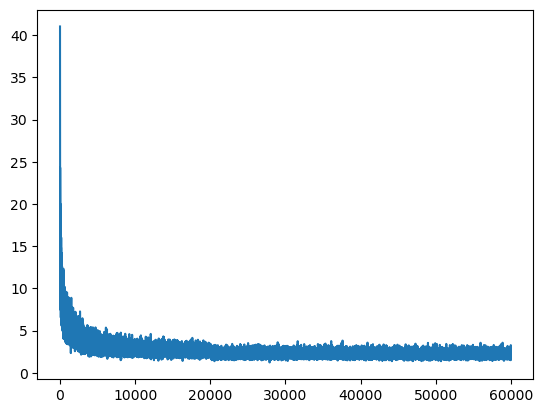

In [24]:
plt.plot(stepi, lossi)

In [25]:
emb = C[Xtr] # (32, 3, 2)
h = torch.tanh(emb.view(-1, W1.shape[0]) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss.item()

2.1776390075683594

In [26]:
emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1, W1.shape[0]) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss.item()

2.2568740844726562

ValueError: x and y must have same first dimension, but have shapes (0,) and (60000,)

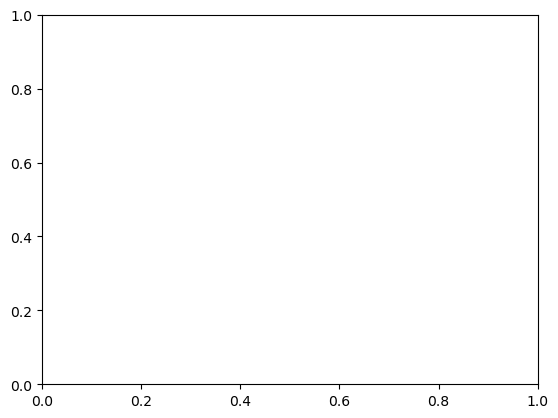

In [27]:
plt.plot(lri, lossi)

In [39]:
# sample from model

for _ in range(20):

    out = []
    context = [0] * 3

    for _ in range(1000):
        emb = C[context] # (1, block_size, d)
        h = torch.tanh(emb.view(1, -1) @ W1 + b1) # (block_size * d, 300)
        logits = h @ W2 + b2 # (block_size*d, 27)
        prob = F.softmax(logits, dim = 1)
        ix = torch.multinomial(prob, num_samples=1).item()
        context = context[1:] + [ix]
        out.append(itos[ix])
        if ix == 0:
            break
    
    print(''.join(out))

elton.
shaniya.
eagom.
tae.
ali.
wamhina.
edler.
meman.
para.
willisejo.
alaya.
aley.
asb.
janyar.
sreen.
brielle.
efinicalex.
yoriia.
raya.
dar.
